In [1]:
from PIL import Image
import os

In [23]:
def process_and_chunk_images(base_path, overlay_path, output_dir, chunk_size=512):
    # 1. Open the images
    # Ensure they are in RGBA mode to handle transparency gracefully if needed
    base_img = Image.open(base_path).convert("RGBA")
    overlay_img = Image.open(overlay_path).convert("RGBA")
    
    # 2. Scale down the overlay image by 0.486 on both dimensions
    new_width = int(overlay_img.width * 0.486)
    new_height = int(overlay_img.height * 0.486)
    # Using Resampling.LANCZOS for high-quality downscaling
    overlay_scaled = overlay_img.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # 3. Combine them using an offset of 144 pixels (Y)
    # This pastes the scaled overlay onto a copy of the base image
    combined_img=Image.new("RGBA", (2048,1792), (0, 0, 0, 0))
    combined_img.alpha_composite(overlay_scaled)
    offset = (-5, 5) 
    
    # We use overlay_scaled as the third argument too so its alpha channel acts as a mask
    combined_img.alpha_composite(base_img, dest=offset)
    
    # Convert back to RGB if you don't need alpha for your game chunks (saves space)
    final_canvas = combined_img.convert("RGBA")
    # Pad to 4096x4096 for Godot (power-of-2, clean 256 tile grid)
    final = Image.new("RGBA", (2048,1792), (0, 0, 0, 0))
    final.paste(final_canvas, (0, 0))
    # 4. Break down into grids/chunks
    os.makedirs(output_dir, exist_ok=True)
    canvas_width, canvas_height = final_canvas.size
    return final_canvas
    chunk_count = 0
    # Loop through the image in steps of the chunk size
    for y in range(0, canvas_height, chunk_size):
        for x in range(0, canvas_width, chunk_size):
            # Define the bounding box for the chunk (left, upper, right, lower)
            box = (x, y, x + chunk_size, y + chunk_size)
            chunk = final_canvas.crop(box)
            
            # Save the chunk with its grid coordinates for easy game engine loading
            chunk_name = f"chunk_y{y//chunk_size}_x{x//chunk_size}.png"
            chunk.save(os.path.join(output_dir, chunk_name))
            chunk_count += 1
            
    print(f"Success! Generated {chunk_count} chunks of size {chunk_size}x{chunk_size} in '{output_dir}'.")



In [24]:
# --- Example Usage ---
if __name__ == "__main__":
    # Replace these with your actual file paths
    OVERLAY_IMAGE_PATH = "Images\\maps\\map1\\contour.png"
    BASE_IMAGE_PATH = "Images\\maps\\map1\\road.png"
    OUTPUT_DIRECTORY = "game_chunks"
    
    # Change chunk_size to 256 if needed
    img=process_and_chunk_images(
        base_path=BASE_IMAGE_PATH,
        overlay_path=OVERLAY_IMAGE_PATH,
        output_dir=OUTPUT_DIRECTORY,
        chunk_size=256  
    )

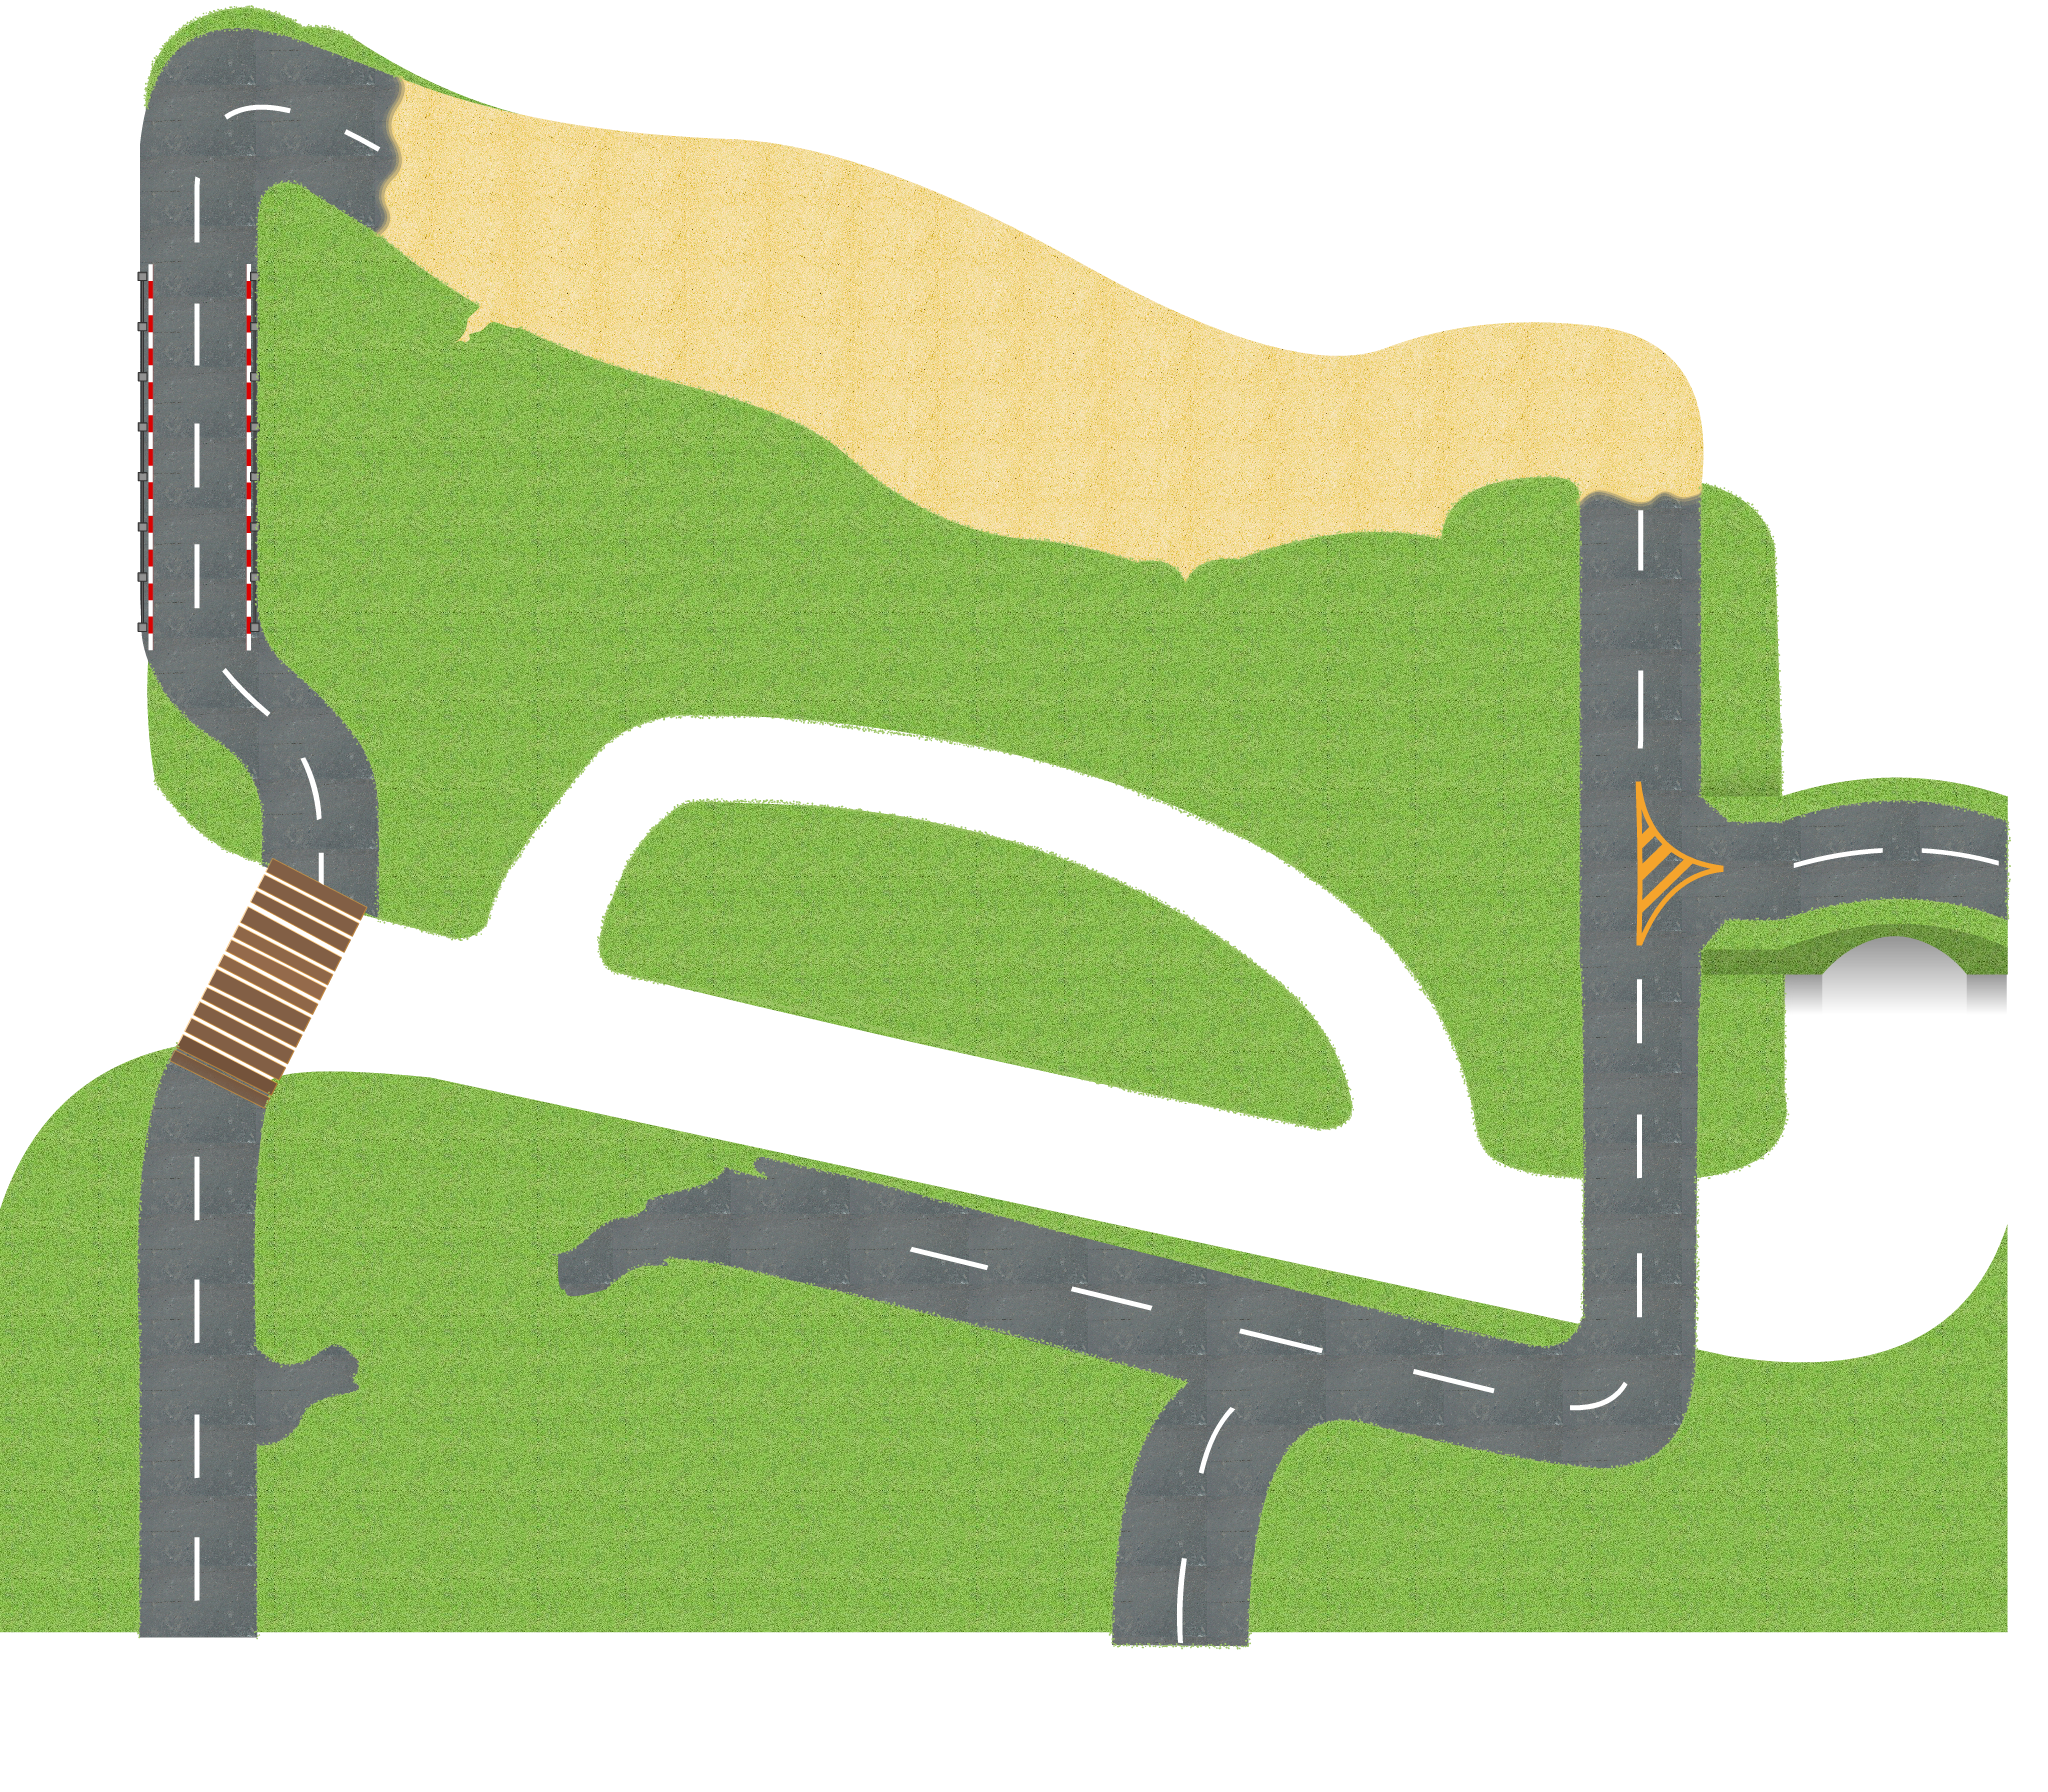

In [25]:
img